# Stage 5 — intrinsic dimensionality (triangulated)

From `src/000447/06_dimensionality.py` on the smoothed 50 ms awake data. No single
estimator is trusted; we read several together (`src/common/dimensionality.py`):

- **TwoNN** — primary model-free intrinsic dimension (bootstrap mean ± sd)
- **PCA participation ratio** — linear UPPER bound (curved manifolds inflate it)
- **Isomap knee** — elbow of residual-variance-vs-dimension
- **Decoding-vs-dimension** — CV decoding of position & novelty vs. PCA dim; the
  saturation point is the behaviourally-relevant dimension

The **TwoNN − participation-ratio gap** is itself a curvature signal (linear
over-counting). Estimators use random subsamples (geometry) and strided
contiguous subsamples (decoding), never the full autocorrelated matrix.

## Setup

In [1]:
import sys, pathlib
_root = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "src" / "common" / "config.py").exists())
for _d in ("common", "000447"):
    sys.path.insert(0, str(_root / "src" / _d))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from config import processed_dir
DATA_PROCESSED = processed_dir("000447")
plt.rcParams["figure.dpi"] = 100
summ = pd.read_csv(DATA_PROCESSED / "stage5_dim_summary.csv")
curves = pd.read_csv(DATA_PROCESSED / "stage5_dim_curves.csv")
print("groups:", len(summ), "| subjects:", summ.subject.nunique())
summ[summ.condition == "all"].groupby("region")[
    ["twonn", "participation_ratio", "isomap_knee", "decode_pos_sat", "decode_label_sat"]
].mean().round(1)

groups: 30 | subjects: 5


,twonn,participation_ratio,isomap_knee,decode_pos_sat,decode_label_sat
region,,,,,
CA1,4.4,12.6,4.4,12.8,6.6
PFC,4.9,7.4,5.2,13.6,5.2


## 1. Triangulated dimensionality per subject × region (condition = all)

TwoNN (green, ± bootstrap sd) and the Isomap knee (cyan) — two intrinsic
estimates — vs. the linear PCA participation ratio (purple). Intrinsic well below
linear ⇒ a low-dimensional but curved manifold.

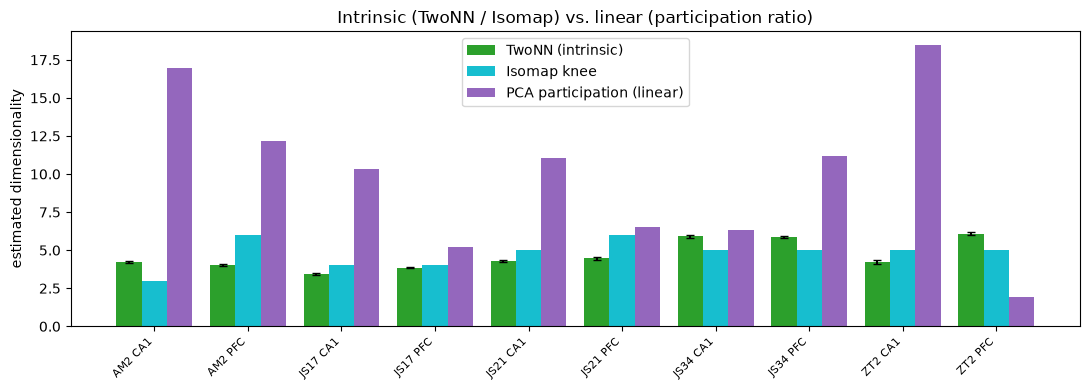

In [2]:
a = summ[summ.condition == "all"].copy()
a["label"] = a.subject.str.split("-").str[-1] + " " + a.region
x = np.arange(len(a)); w = 0.27
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(x - w, a.twonn, w, yerr=a.twonn_sd, capsize=3, label="TwoNN (intrinsic)", color="tab:green")
ax.bar(x, a.isomap_knee, w, label="Isomap knee", color="tab:cyan")
ax.bar(x + w, a.participation_ratio, w, label="PCA participation (linear)", color="tab:purple")
ax.set_xticks(x); ax.set_xticklabels(a.label, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("estimated dimensionality"); ax.legend()
ax.set_title("Intrinsic (TwoNN / Isomap) vs. linear (participation ratio)")
plt.tight_layout()

## 2. Decoding vs. dimension

Cross-validated decoding (mean over subjects × regions) as PCA latent dimension
grows: position R² and novelty (novel/familiar) classification accuracy. Both
saturate within a handful of dimensions — the behaviourally-relevant geometry is
low-dimensional.

,decode_pos_sat,decode_label_sat
region,,
CA1,12.8,6.6
PFC,13.6,5.2


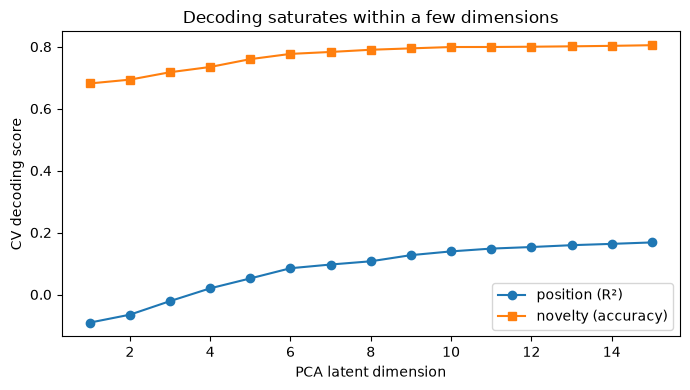

In [3]:
c = curves[curves.condition == "all"]
mp = c.groupby("dim")[["decode_pos", "decode_label"]].mean()
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(mp.index, mp.decode_pos, "-o", color="tab:blue", label="position (R²)")
ax.plot(mp.index, mp.decode_label, "-s", color="tab:orange", label="novelty (accuracy)")
ax.set_xlabel("PCA latent dimension"); ax.set_ylabel("CV decoding score")
ax.set_title("Decoding saturates within a few dimensions"); ax.legend()
plt.tight_layout()
summ[summ.condition == "all"].groupby("region")[["decode_pos_sat", "decode_label_sat"]].mean().round(1)

## 3. The curvature gap

Each point is one subject×region: TwoNN intrinsic dimension (x) vs. the linear
participation ratio (y). Points above the diagonal mean the linear method
over-counts — the manifold is curved. Novel vs. familiar shown separately to see
whether familiarization changes the geometry's curvature.

twonn  participation_ratio
region condition                            
CA1    all          4.4                 12.6
       familiar     3.5                 10.3
       novel        3.8                 11.9
PFC    all          4.9                  7.4
       familiar     4.0                  5.6
       novel        4.2                  7.4

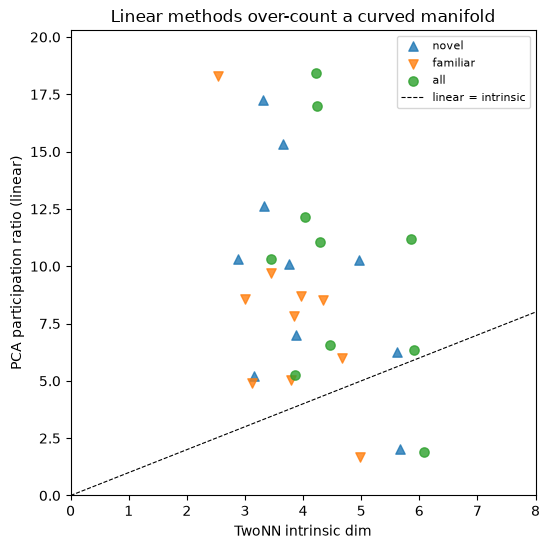

In [4]:
fig, ax = plt.subplots(figsize=(5.6, 5.6))
COND_MK = {"novel": "^", "familiar": "v", "all": "o"}
for cond, mk in COND_MK.items():
    r = summ[summ.condition == cond]
    ax.scatter(r.twonn, r.participation_ratio, marker=mk, s=45, alpha=0.8, label=cond)
lim = [0, summ.participation_ratio.max() * 1.1]
ax.plot(lim, lim, "k--", lw=0.8, label="linear = intrinsic")
ax.set_xlim(0, 8); ax.set_ylim(0, lim[1])
ax.set_xlabel("TwoNN intrinsic dim"); ax.set_ylabel("PCA participation ratio (linear)")
ax.set_title("Linear methods over-count a curved manifold"); ax.legend(fontsize=8)
plt.tight_layout()
summ.groupby(["region", "condition"])[["twonn", "participation_ratio"]].mean().round(1)

---
**Takeaway:** the novel/familiar cognitive maps occupy a **low-dimensional curved
manifold** — TwoNN and the Isomap knee agree at ~3–5 intrinsic dimensions, well
under the linear participation ratio, and CV decoding of position/novelty
saturates in the same range. The intrinsic−linear gap is the curvature the
downstream nonlinear embeddings (UMAP/CEBRA) are built to respect.

(This supersedes the earlier 1000 ms bi-cross-validation linear estimate, which
was censored/high-dimensional because linear reconstruction counts private
per-neuron variance rather than the shared behavioural manifold.)